# <b>House Price Prediction</b>

## <b>Phase 7 – Baseline Model Building</b>

### <b>Objective</b>

In this notebook, we build the first machine learning model using Linear Regression.

Tasks covered:

- Load processed datasets
- Train Linear Regression model
- Make predictions
- Evaluate model
- Visualize results
- Save trained model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 13)
X_test : (109, 13)
y_train: (436,)
y_test : (109,)


In [4]:
linear_model = LinearRegression()

In [5]:
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 519552.42, 57349.56, 521879.03,..., 266656.35, -62837.32,-192015.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.707e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [6]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,area,519552.416340
1,bedrooms,57349.559419
2,bathrooms,521879.027748
3,stories,349251.438906
4,mainroad,128498.628215
5,guestroom,88768.667686
6,basement,187067.803214
7,hotwaterheating,149862.702991
8,airconditioning,365157.393851
9,parking,192005.953667


In [7]:
print("Intercept:", linear_model.intercept_)

Intercept: 4706527.385321101


In [8]:
y_pred = linear_model.predict(X_test)

In [9]:
prediction_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

prediction_df.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 970043.40
MSE  : 1754318687330.67
RMSE : 1324506.96
R²   : 0.6529


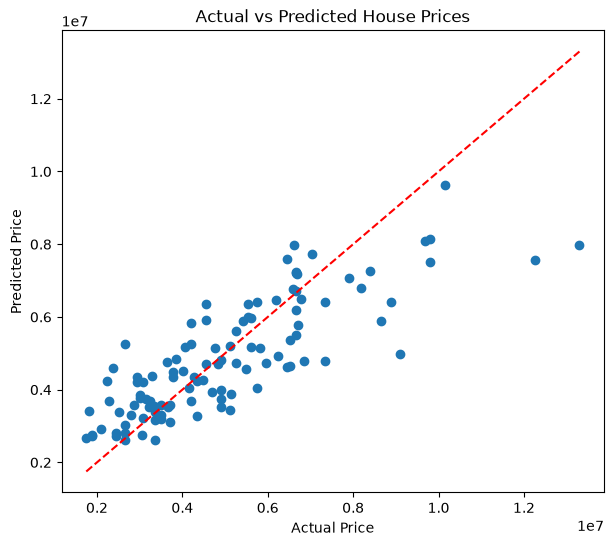

In [11]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

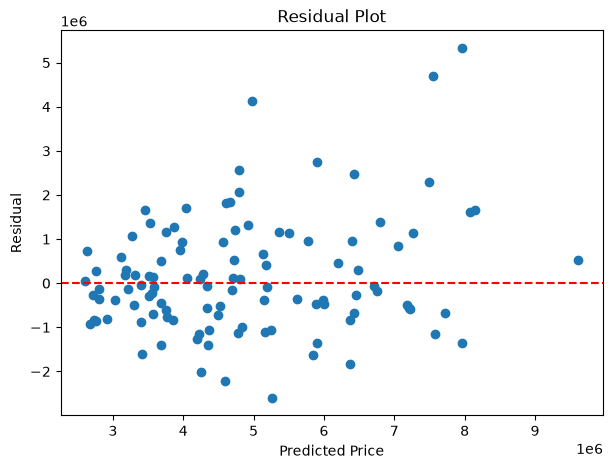

In [12]:
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [13]:
joblib.dump(
    linear_model,
    "../models/linear_regression_model.pkl"
)

['../models/linear_regression_model.pkl']

#### <b>Baseline Model Summary</b>

Algorithm Used:
- Linear Regression

Evaluation Metrics:
- MAE
- MSE
- RMSE
- R² Score

Visualizations:
- Actual vs Predicted Plot
- Residual Plot

Outcome:
The Linear Regression model serves as the baseline for comparison with more advanced regression algorithms in the next phase.